# Tutorial 7 — Few-Shot Learning for NMR Chemical Shift Prediction

**Paper we are reproducing (gradually, in a lightweight form):**

> Han, H.; Choi, S. *Transfer Learning from Simulation to Experimental Data: NMR Chemical Shift Predictions.*
> J. Phys. Chem. Lett. **2021**, 12, 3662–3668. https://doi.org/10.1021/acs.jpclett.1c00578

**Core idea of the paper.** Quantum-chemistry (DFT) simulations can generate large amounts of NMR shielding
data cheaply, but they are not the same physical quantity as an experimentally measured chemical shift (δ),
and DFT-only models transfer poorly to experiment. Instead of throwing away the simulation data, the authors
**pretrain** a graph neural network (GNN) on a large *simulated* database (QM9 + DFT-computed shielding
constants, σ), then **fine-tune** it on a *small* amount of real experimental data (NMRShiftDB2). This is a
textbook example of **transfer learning** applied to a few-shot regime: with fine-tuning on as little as
1–10% of the experimental training set, the model matches or beats models trained on the *full* experimental
set from scratch.

**What you will do in this notebook, gradually:**

- **(a)** Build the GNN architecture from the paper and train it on a small subset of *computed* (DFT) data.
- **(b)** Reproduce the paper's central result: fine-tuning accuracy improves as you add more experimental data.
- **(c)** Understand what fine-tuning actually changes in the network, and interactively explore how
  fine-tuning hyperparameters (learning rate, frozen layers, epochs) affect the outcome.
- **(d)** Compare the transfer-learning model against three alternatives: a model trained on experimental
  data only (no pretraining), a model trained only on "common" molecules (removing chemical environments
  the pretrained model never saw), and a classical k-nearest-neighbors baseline.
- **Challenge:** predict $\delta(^1H)$ on a held-out test set and submit your predictions to the live
  class leaderboard.

**A note on scale.** The paper pretrains on ~130,000 simulated molecules and fine-tunes on up to ~9,700
experimental molecules. That does not fit in a 105-minute live session. This notebook uses small, *real*
subsets of the same public datasets so every result you compute is genuine (not synthetic), while staying
fast enough to run cell-by-cell in class. Pointers to the full-scale datasets are given at the end for
anyone who wants to go further.


## 0 · Setup

Run this once. Colab already has PyTorch; we additionally need RDKit for molecule handling and `ipywidgets` for the interactive demo in part (c).

In [1]:
!pip -q install rdkit ipywidgets openpyxl > /dev/null

import io, os, json, math, pickle, gzip, tarfile, urllib.request, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from rdkit import Chem
from rdkit.Chem import AllChem

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cpu


## (a) · The GNN architecture, trained on a subset of computed data

### 2.1 Background: σ vs. δ

DFT gives you an **isotropic magnetic shielding constant**, σ, for every atom. What you actually measure
in an NMR experiment is a **chemical shift**, δ, referenced against a standard (e.g. TMS):

$$\delta = \frac{\sigma_{ref} - \sigma}{1 - \sigma_{ref}} \approx \sigma_{ref} - \sigma$$

The two are related but not identical, and the relationship is noisier than the formula suggests once you
leave idealized gas-phase DFT (solvent, temperature, referencing conventions, etc. all matter). This is
exactly why the paper doesn't just apply a linear correction — it *transfer-learns* a network trained to
predict σ into a network that predicts δ.

### 2.2 Architecture (Figure 1a of the paper)

The model is a **message-passing neural network (MPNN)** operating directly on 3D atomic coordinates
(not just the bonded graph):

1. **Node features** — each atom's atomic number is embedded into a vector (entity embedding).
2. **Edge features** — the distance between *every pair* of atoms is expanded with a bank of Gaussian
   radial basis functions, `exp(-α(d - d_j)²)`. This makes the network aware of 3D geometry, not just
   connectivity.
3. **Message passing** — 4 stacked MPNN layers. Each layer computes messages with an *edge network*
   (a small MLP maps each edge feature to a matrix that transforms the neighbor's hidden state) and updates
   node states with a **GRU**.
4. **Readout** — a separate linear head per chemical element maps the final atom embedding to σ (or δ,
   after fine-tuning).

The paper uses an embedding size of 256 and stacks 4 MPNN layers, trained for up to 200 epochs. We use a
smaller version (`HIDDEN_DIM = 64`, `N_LAYERS = 3`) purely so that training fits inside a few seconds/minutes
in class — the architecture is otherwise the same. Everything you learn about how it behaves generalizes to
the full-size model.


In [2]:
# Elements seen in the *simulated* database (QM9-like): H, C, N, O, F
# The *experimental* database additionally contains P, S, Cl (see part (d)).
ELEMENTS = ['H', 'C', 'N', 'O', 'F', 'P', 'S', 'Cl']
ELEMENT_TO_IDX = {e: i for i, e in enumerate(ELEMENTS)}

HIDDEN_DIM = 64      # paper uses 256 -- reduced for speed in class
N_LAYERS = 3          # paper uses 4   -- reduced for speed in class
N_GAUSSIANS = 32      # paper uses a 0-15 Angstrom mesh at 0.1 Angstrom spacing (151 centers) -- reduced
CUTOFF = 10.0         # Angstrom, generous for small molecules

GAUSSIAN_CENTERS = torch.linspace(0, CUTOFF, N_GAUSSIANS)
GAUSSIAN_ALPHA = 0.5


def gaussian_distance_expansion(dist):
    """dist: (..., ) tensor of distances -> (..., N_GAUSSIANS) expanded features."""
    diff = dist.unsqueeze(-1) - GAUSSIAN_CENTERS.to(dist.device)
    return torch.exp(-GAUSSIAN_ALPHA * diff.pow(2))


class EdgeNetworkMPNNLayer(nn.Module):
    """One message-passing layer: edge network (Gilmer et al. 2017) + GRU node update,
    matching the paper's description (edge network message function, GRU update function)."""

    def __init__(self, hidden_dim, edge_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Edge network: edge feature -> (hidden_dim x hidden_dim) transformation matrix
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim * hidden_dim),
        )
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)

    def forward(self, node_h, edge_feat, adj_mask):
        """
        node_h:   (B, N, H)      current node hidden states
        edge_feat:(B, N, N, E)   Gaussian-expanded pairwise distances
        adj_mask: (B, N, N)      1 where atom pair is a valid (real, i != j) pair, else 0
        """
        B, N, H = node_h.shape
        W = self.edge_mlp(edge_feat).view(B, N, N, H, H)          # per-edge transform matrix
        # message_ij = W_ij @ node_h_j
        msg = torch.einsum('bijhk,bjk->bijh', W, node_h)           # (B, N, N, H)
        msg = msg * adj_mask.unsqueeze(-1)
        agg = msg.sum(dim=2)                                       # sum over neighbors j -> (B, N, H)

        node_h_flat = node_h.reshape(B * N, H)
        agg_flat = agg.reshape(B * N, H)
        new_h = self.gru(agg_flat, node_h_flat).reshape(B, N, H)
        return new_h


class NMRTransferGNN(nn.Module):
    """Full model: atom embedding -> N x (edge-network + GRU) MPNN layers -> per-element readout."""

    def __init__(self, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS, n_gaussians=N_GAUSSIANS,
                 n_elements=len(ELEMENTS)):
        super().__init__()
        self.atom_embed = nn.Embedding(n_elements, hidden_dim)
        self.layers = nn.ModuleList([
            EdgeNetworkMPNNLayer(hidden_dim, n_gaussians) for _ in range(n_layers)
        ])
        # One linear readout head PER ELEMENT -- this is what gets re-initialized during fine-tuning
        self.readout = nn.ModuleDict({e: nn.Linear(hidden_dim, 1) for e in ELEMENTS})
        self.dropout = nn.Dropout(0.1)

    def forward(self, atom_idx, dist, adj_mask, element_symbols):
        """
        atom_idx: (B, N) long          index into ELEMENTS for each atom (padding uses -1 -> masked out)
        dist:     (B, N, N) float      pairwise distances
        adj_mask: (B, N, N) float      1 for valid pairs
        element_symbols: list of lists, element_symbols[b][i] = symbol string for atom i in graph b
        returns: (B, N) predicted scalar (sigma or delta) per atom
        """
        B, N = atom_idx.shape
        safe_idx = atom_idx.clamp(min=0)
        h = self.atom_embed(safe_idx)                    # (B, N, H)
        edge_feat = gaussian_distance_expansion(dist)      # (B, N, N, N_GAUSSIANS)

        for layer in self.layers:
            h = self.dropout(layer(h, edge_feat, adj_mask))

        out = torch.zeros(B, N, device=h.device)
        for b in range(B):
            for i in range(N):
                sym = element_symbols[b][i]
                if sym is None:
                    continue
                out[b, i] = self.readout[sym](h[b, i]).squeeze(-1)
        return out


print(f"Model defined: {N_LAYERS} MPNN layers, hidden dim {HIDDEN_DIM}, "
      f"{sum(p.numel() for p in NMRTransferGNN().parameters()):,} parameters "
      f"(paper's full-size model has ~a few million).")


Model defined: 3 MPNN layers, hidden dim 64, 481,416 parameters (paper's full-size model has ~a few million).


### 2.3 A small subset of *computed* (DFT) data

The paper's simulation database is QM9 + shielding constants computed by Bratholm et al. (85k/46k
train/test molecules, hosted on OSF, https://osf.io/46dpj/ — too large for a live session). We use a
public, directly-downloadable subset that is computed at essentially the same level of theory and
covers the same kind of chemical space (small QM9-like organic molecules): the **QM9NMR "GDB10–17" case
study** released by Gupta, Chakraborty & Ramakrishnan (Mach. Learn.: Sci. Technol. 2021) alongside the
Bratholm-style dataset, 200 molecules computed at mPW1PW91/6-311+G(2d,p).

> **Exercise.** Fill in the missing piece of the parser below: for each atom, you need to look up its
> isotropic shielding value from the `NMR.txt` block and match it to the corresponding line of the
> `.xyz` geometry block.


In [3]:
GDB_GEO_URL = "https://moldis-group.github.io/qm9nmr/data/SI_GDB10to17_DFT_geo.xyz"
GDB_NMR_URL = "https://moldis-group.github.io/qm9nmr/data/SI_GDB10to17_DFT_NMR.txt"

def download_text(url):
    with urllib.request.urlopen(url, timeout=30) as r:
        return r.read().decode("utf-8", errors="ignore")

geo_text = download_text(GDB_GEO_URL)
nmr_text = download_text(GDB_NMR_URL)
print(geo_text[:300])
print("---")
print(nmr_text[:300])


017
G10_00184 
C    -2.85119900     1.00615500     0.00051500     
C    -1.58637400     0.20212000     0.00003400     
N    -1.53469900    -1.07921600    -0.00041400     
O    -2.79559800    -1.64948100    -0.00026700     
C    -0.27048200     0.93020900    -0.00007400     
O    -0.26997500     2.14
---
017
G10_00184 
C        178.0971
C         22.1398
N       -165.0045
O         93.7343
C          2.7127
O       -283.2125
C         63.5571
C         18.9438
O        -91.8544
N       -158.3296
C         31.1164
H         29.9872
H         28.7159
H         29.9857
H         24.8822
H         22.30


In [4]:
def parse_xyz_blocks(text):
    """Standard multi-molecule XYZ: first line = n_atoms, second = comment, then n_atoms lines."""
    lines = text.strip().splitlines()
    mols, i = [], 0
    while i < len(lines):
        n = int(lines[i].strip())
        name = lines[i + 1].strip()
        atoms, coords = [], []
        for j in range(n):
            parts = lines[i + 2 + j].split()
            atoms.append(parts[0])
            coords.append([float(x) for x in parts[1:4]])
        mols.append({"name": name, "atoms": atoms, "coords": np.array(coords)})
        i += 2 + n
    return mols


def parse_nmr_blocks(text):
    """Matches parse_xyz_blocks: n_atoms line, name line, then n_atoms lines of 'element  shielding'."""
    lines = text.strip().splitlines()
    mols, i = [], 0
    while i < len(lines):
        n = int(lines[i].strip())
        name = lines[i + 1].strip()
        shieldings = []
        for j in range(n):
            parts = lines[i + 2 + j].split()
            ### YOUR CODE HERE ###
            # `parts` looks like: [element_symbol, isotropic_shielding, ...maybe more columns...]
            # Append the isotropic shielding value (as a float) to `shieldings`.
            shieldings.append(float(parts[1]))
            ### END YOUR CODE ###
        mols.append({"name": name, "shieldings": np.array(shieldings)})
        i += 2 + n
    return mols


geo_mols = parse_xyz_blocks(geo_text)
nmr_mols = parse_nmr_blocks(nmr_text)
assert len(geo_mols) == len(nmr_mols), "geometry/NMR molecule counts do not match"

computed_dataset = []
for g, s in zip(geo_mols, nmr_mols):
    assert g["name"] == s["name"]
    computed_dataset.append({"name": g["name"], "atoms": g["atoms"], "coords": g["coords"],
                              "sigma": s["shieldings"]})

print(f"Loaded {len(computed_dataset)} computed (DFT) molecules.")
print("Example:", computed_dataset[0]["name"], computed_dataset[0]["atoms"][:5], "...")


Loaded 200 computed (DFT) molecules.
Example: G10_00184 ['C', 'C', 'N', 'O', 'C'] ...


In [5]:
def mol_to_tensors(atoms, coords, target=None, n_max=40):
    """Pads a single molecule into fixed-size tensors for batching."""
    n = len(atoms)
    assert n <= n_max, f"molecule with {n} atoms exceeds n_max={n_max}"
    atom_idx = torch.full((n_max,), -1, dtype=torch.long)
    symbols = [None] * n_max
    for i, a in enumerate(atoms):
        atom_idx[i] = ELEMENT_TO_IDX[a]
        symbols[i] = a
    dist = torch.zeros(n_max, n_max)
    adj_mask = torch.zeros(n_max, n_max)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            d = np.linalg.norm(coords[i] - coords[j])
            dist[i, j] = d
            adj_mask[i, j] = 1.0
    y = torch.zeros(n_max)
    y_mask = torch.zeros(n_max)
    if target is not None:
        y[:n] = torch.tensor(target, dtype=torch.float32)
        y_mask[:n] = 1.0
    return atom_idx, dist, adj_mask, symbols, y, y_mask


def collate(batch_dicts, n_max=40):
    atom_idx_l, dist_l, adj_l, sym_l, y_l, ymask_l = [], [], [], [], [], []
    for d in batch_dicts:
        atom_idx, dist, adj_mask, symbols, y, y_mask = mol_to_tensors(
            d["atoms"], d["coords"], d.get("target"), n_max)
        atom_idx_l.append(atom_idx); dist_l.append(dist); adj_l.append(adj_mask)
        sym_l.append(symbols); y_l.append(y); ymask_l.append(y_mask)
    return (torch.stack(atom_idx_l), torch.stack(dist_l), torch.stack(adj_l),
            sym_l, torch.stack(y_l), torch.stack(ymask_l))


# quick smoke test on 4 molecules
sample_batch = [{"atoms": m["atoms"], "coords": m["coords"], "target": m["sigma"]}
                 for m in computed_dataset[:4] if len(m["atoms"]) <= 32]
atom_idx, dist, adj_mask, symbols, y, y_mask = collate(sample_batch)
print(atom_idx.shape, dist.shape, adj_mask.shape, y.shape)


torch.Size([4, 40]) torch.Size([4, 40, 40]) torch.Size([4, 40, 40]) torch.Size([4, 40])


### 2.4 Pretrain on the computed subset

Train the architecture above to predict σ from 3D structure, on our small computed subset. This is a toy
version of the paper's pretraining stage — same objective (predict shielding from geometry), same
architecture family, much smaller data and much shorter training so it fits in class.


In [6]:
def make_loader(dataset_list, batch_size=8, n_max=40, shuffle=True):
    items = [d for d in dataset_list if len(d["atoms"]) <= n_max]
    idxs = list(range(len(items)))
    if shuffle:
        random.shuffle(idxs)
    for start in range(0, len(idxs), batch_size):
        batch = [items[i] for i in idxs[start:start + batch_size]]
        yield batch


def train_epoch(model, dataset_list, optimizer, n_max=40, batch_size=8):
    model.train()
    losses = []
    for batch in make_loader(dataset_list, batch_size=batch_size, n_max=n_max):
        batch_dicts = [{"atoms": d["atoms"], "coords": d["coords"], "target": d["sigma"]} for d in batch]
        atom_idx, dist, adj_mask, symbols, y, y_mask = collate(batch_dicts, n_max=n_max)
        atom_idx, dist, adj_mask, y, y_mask = [t.to(DEVICE) for t in (atom_idx, dist, adj_mask, y, y_mask)]
        pred = model(atom_idx, dist, adj_mask, symbols)
        loss = (F.l1_loss(pred, y, reduction='none') * y_mask).sum() / y_mask.sum().clamp(min=1)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


@torch.no_grad()
def evaluate(model, dataset_list, n_max=40, batch_size=16):
    model.eval()
    abs_errs = []
    for batch in make_loader(dataset_list, batch_size=batch_size, n_max=n_max, shuffle=False):
        batch_dicts = [{"atoms": d["atoms"], "coords": d["coords"], "target": d["sigma"] if "sigma" in d else d["target"]} for d in batch]
        atom_idx, dist, adj_mask, symbols, y, y_mask = collate(batch_dicts, n_max=n_max)
        atom_idx, dist, adj_mask, y, y_mask = [t.to(DEVICE) for t in (atom_idx, dist, adj_mask, y, y_mask)]
        pred = model(atom_idx, dist, adj_mask, symbols)
        errs = (pred - y).abs()[y_mask.bool()]
        abs_errs.append(errs.cpu().numpy())
    return float(np.concatenate(abs_errs).mean()) if abs_errs else float('nan')


random.shuffle(computed_dataset)
n_train = int(0.8 * len(computed_dataset))
computed_train, computed_test = computed_dataset[:n_train], computed_dataset[n_train:]

pretrained_model = NMRTransferGNN().to(DEVICE)
optimizer = torch.optim.Adam(pretrained_model.parameters(), lr=1e-3)

history = []
N_PRETRAIN_EPOCHS = 15   # paper trains up to 200 epochs on 85k molecules; 15 epochs on 200 molecules is enough to see the trend
for epoch in range(N_PRETRAIN_EPOCHS):
    train_loss = train_epoch(pretrained_model, computed_train, optimizer)
    if epoch % 3 == 0 or epoch == N_PRETRAIN_EPOCHS - 1:
        test_mae = evaluate(pretrained_model, computed_test)
        history.append((epoch, train_loss, test_mae))
        print(f"epoch {epoch:2d}  train L1 {train_loss:6.3f}  test MAE(sigma) {test_mae:6.3f} ppm")


epoch  0  train L1 77.056  test MAE(sigma) 76.669 ppm
epoch  3  train L1 73.361  test MAE(sigma) 73.374 ppm
epoch  6  train L1 70.193  test MAE(sigma) 69.961 ppm
epoch  9  train L1 66.810  test MAE(sigma) 66.486 ppm
epoch 12  train L1 63.435  test MAE(sigma) 62.961 ppm
epoch 14  train L1 60.792  test MAE(sigma) 60.522 ppm


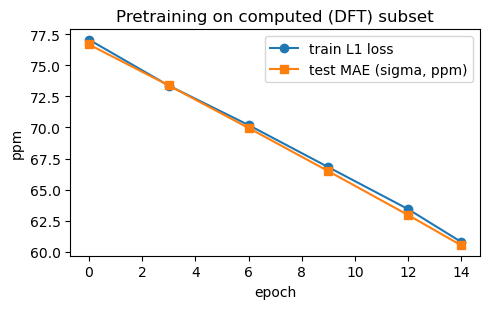

In [7]:
epochs_, train_losses_, test_maes_ = zip(*history)
plt.figure(figsize=(5, 3.2))
plt.plot(epochs_, train_losses_, marker='o', label='train L1 loss')
plt.plot(epochs_, test_maes_, marker='s', label='test MAE (sigma, ppm)')
plt.xlabel('epoch'); plt.ylabel('ppm'); plt.legend(); plt.title('Pretraining on computed (DFT) subset')
plt.tight_layout(); plt.show()


## (b) · More experimental data → better fine-tuned accuracy

This is the paper's central empirical result (their Figure 1c/d): fine-tuning MAE on the experimental test
set drops monotonically as you increase the fraction of the experimental *training* set used for
fine-tuning. We reproduce the shape of that curve here with real experimental data.

### 3.1 Load a real experimental 1H dataset

We use the NMRShiftDB2-derived dataset released as supplementary data by Jonas & Kuhn (*J. Cheminf.* 2019)
and reused by Kwon et al. (*J. Chem. Inf. Model.* 2020) — this is the same experimental database lineage
cited by Han & Choi (their refs 4, 6, 25, 26). It ships as a pickled pandas DataFrame with an RDKit `Mol`
per row and a `value` column mapping atom index → measured shift.


In [8]:
MOESM_URL = "https://static-content.springer.com/esm/art%3A10.1186%2Fs13321-019-0374-3/MediaObjects/13321_2019_374_MOESM2_ESM.gz"
LOCAL_GZ = "nmr_data_archive.gz"
LOCAL_PICKLE = "data_1H.pickle"

# This supplementary file is a gzip-compressed tarball of the Jonas & Kuhn (2019) code + data
# release. The 1H pickle inside is NOT named "data_1H.pickle" -- it is nested under a long,
# dataset-specific filename that contains ".1H." (e.g. "...data.1H.nmrshiftdb_....mol_dict.pickle"),
# so we search for that substring rather than hard-coding an exact filename.
if not os.path.exists(LOCAL_PICKLE):
    print("Downloading experimental 1H NMR dataset (Jonas & Kuhn, 2019 SI)...")
    urllib.request.urlretrieve(MOESM_URL, LOCAL_GZ)

    assert tarfile.is_tarfile(LOCAL_GZ), (
        f"Expected '{LOCAL_GZ}' to be a tar.gz archive -- open it manually to inspect its format.")
    with tarfile.open(LOCAL_GZ, "r:*") as tf:
        names = tf.getnames()
        print("Archive contents:", names)
        members = [m for m in tf.getmembers()
                   if ".1H." in os.path.basename(m.name) and m.name.endswith(".pickle")]
        assert members, (f"Could not find a '*.1H.*.pickle' member in the archive; "
                          f"contents were: {names}")
        member = members[0]
        member.name = os.path.basename(member.name)
        tf.extract(member, ".")
        if member.name != LOCAL_PICKLE:
            os.replace(member.name, LOCAL_PICKLE)

# Use pd.read_pickle (not raw pickle.load) -- pandas needs its own unpickling machinery to
# correctly restore DataFrame/Index internals saved by an older pandas version.
nmr_1h = pd.read_pickle(LOCAL_PICKLE)

train_df = nmr_1h["train_df"]
test_df = nmr_1h["test_df"]
print(f"Experimental 1H database: {len(train_df)} training molecules, {len(test_df)} test molecules.")
train_df.head(3)


Archive contents: ['atom_features.py', 'graph_conv_many_nuc_pred.py', 'graph_conv_many_nuc_util.py', 'molecule_features.py', 'netdataio.py', 'nets.py', 'respredict_pipeline.py', 'util.py', 'graph_conv_many_nuc_pipeline.datasets/graph_conv_many_nuc_pipeline.data.13C.nmrshiftdb_hconfspcl_nmrshiftdb.aromatic.64.0.mol_dict.pickle', 'graph_conv_many_nuc_pipeline.datasets/graph_conv_many_nuc_pipeline.data.1H.nmrshiftdb_hconfspcl_nmrshiftdb.aromatic.64.1.mol_dict.pickle']
Experimental 1H database: 10252 training molecules, 2554 test molecules.


,molecule_id,rdmol,spectra_ids,value
0,4038,<rdkit.Chem.rdchem.Mol object at 0x3179cb2e0>,[46],"[{27: 1.769, 25: 1.859, 29: 2.683, 23: 2.848, ..."
1,4137,<rdkit.Chem.rdchem.Mol object at 0x3208b13f0>,[153],"[{23: 7.194, 22: 7.598, 18: 7.86, 19: 7.86, 21..."
3,4320,<rdkit.Chem.rdchem.Mol object at 0x3208b13a0>,[355],"[{34: 1.22, 29: 1.67, 33: 2.93, 24: 3.0, 38: 3..."


In [9]:
def df_row_to_example(row, n_max=40):
    mol = row["rdmol"]
    shifts_by_atom = row["value"][0] if isinstance(row["value"], (list, tuple)) else row["value"]
    if mol is None or mol.GetNumAtoms() > n_max:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    if mol.GetNumConformers() == 0:
        try:
            mol = Chem.AddHs(mol)
            AllChem.EmbedMolecule(mol, randomSeed=SEED)
            AllChem.MMFFOptimizeMolecule(mol)
        except Exception:
            return None
    conf = mol.GetConformer()
    atoms, coords, target, has_target = [], [], [], []
    for atom in mol.GetAtoms():
        sym = atom.GetSymbol()
        if sym not in ELEMENT_TO_IDX:
            return None  # skip molecules with elements outside our vocabulary
        pos = conf.GetAtomPosition(atom.GetIdx())
        atoms.append(sym)
        coords.append([pos.x, pos.y, pos.z])
        idx = atom.GetIdx()
        if idx in shifts_by_atom:
            target.append(shifts_by_atom[idx]); has_target.append(1.0)
        else:
            target.append(0.0); has_target.append(0.0)
    if sum(has_target) == 0:
        return None
    return {"atoms": atoms, "coords": np.array(coords), "target": np.array(target),
            "has_target": np.array(has_target)}


### YOUR CODE HERE ###
# Build `experimental_train_all` and `experimental_test_all` by applying df_row_to_example to every
# row of train_df / test_df, skipping any rows where the function returns None. Keep this cell fast:
# limit to the first 1500 train rows and 400 test rows so parsing/embedding finishes in a couple of minutes.
experimental_train_all = [ex for ex in (df_row_to_example(r) for _, r in train_df.head(1500).iterrows()) if ex is not None]
experimental_test_all  = [ex for ex in (df_row_to_example(r) for _, r in test_df.head(400).iterrows()) if ex is not None]
### END YOUR CODE ###

print(f"Usable examples -- train: {len(experimental_train_all)}, test: {len(experimental_test_all)}")


Usable examples -- train: 1331, test: 330


Note the mask: not every H atom in every molecule has a measured shift (`has_target`), and the evaluation below only scores atoms that do.

In [10]:
def evaluate_delta(model, dataset_list, n_max=40, batch_size=16):
    model.eval()
    abs_errs = []
    with torch.no_grad():
        for batch in make_loader(dataset_list, batch_size=batch_size, n_max=n_max, shuffle=False):
            batch_dicts = [{"atoms": d["atoms"], "coords": d["coords"], "target": d["target"]} for d in batch]
            atom_idx, dist, adj_mask, symbols, y, _ = collate(batch_dicts, n_max=n_max)
            has_target = torch.zeros_like(y)
            for bi, d in enumerate(batch):
                n = len(d["atoms"])
                has_target[bi, :n] = torch.tensor(d["has_target"], dtype=torch.float32)
            atom_idx, dist, adj_mask, y, has_target = [t.to(DEVICE) for t in (atom_idx, dist, adj_mask, y, has_target)]
            pred = model(atom_idx, dist, adj_mask, symbols)
            errs = (pred - y).abs()[has_target.bool()]
            if errs.numel():
                abs_errs.append(errs.cpu().numpy())
    return float(np.concatenate(abs_errs).mean()) if abs_errs else float('nan')


def clone_pretrained(pretrained):
    """Fresh copy of the pretrained model with readout heads AND embeddings for P/S/Cl re-initialized,
    matching the paper (readout layers are re-initialized; new-element embeddings are random since they
    were never trained during pretraining on the H/C/N/O/F-only simulation database)."""
    import copy
    m = copy.deepcopy(pretrained)
    for e in ELEMENTS:
        m.readout[e] = nn.Linear(HIDDEN_DIM, 1).to(DEVICE)
    with torch.no_grad():
        for e in ['P', 'S', 'Cl']:
            idx = ELEMENT_TO_IDX[e]
            m.atom_embed.weight[idx] = torch.randn(HIDDEN_DIM) * 0.1
    return m.to(DEVICE)


def fine_tune(pretrained, train_subset, n_epochs=20, lr=1e-4, n_frozen_layers=2, warmup_epochs=5,
              verbose=False):
    """Fine-tunes a copy of `pretrained` on `train_subset`.
    n_frozen_layers: how many of the first MPNN layers to freeze (paper freezes the first 2 of 4).
    LR schedule: linear warmup for `warmup_epochs`, then cosine decay -- matches the paper's schedule."""
    model = clone_pretrained(pretrained)
    for i, layer in enumerate(model.layers):
        if i < n_frozen_layers:
            for p in layer.parameters():
                p.requires_grad = False

    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    def lr_at(epoch):
        if epoch < warmup_epochs:
            return lr * (epoch + 1) / warmup_epochs
        t = (epoch - warmup_epochs) / max(1, n_epochs - warmup_epochs)
        return lr * 0.5 * (1 + math.cos(math.pi * t))

    losses = []
    for epoch in range(n_epochs):
        for g in optimizer.param_groups:
            g['lr'] = lr_at(epoch)
        train_loss = train_epoch_delta(model, train_subset, optimizer)
        losses.append(train_loss)
        if verbose and (epoch % max(1, n_epochs // 5) == 0):
            print(f"  epoch {epoch:3d}  lr {lr_at(epoch):.2e}  train L1 {train_loss:.3f}")
    return model, losses


def train_epoch_delta(model, dataset_list, optimizer, n_max=40, batch_size=8):
    model.train()
    losses = []
    for batch in make_loader(dataset_list, batch_size=batch_size, n_max=n_max):
        batch_dicts = [{"atoms": d["atoms"], "coords": d["coords"], "target": d["target"]} for d in batch]
        atom_idx, dist, adj_mask, symbols, y, _ = collate(batch_dicts, n_max=n_max)
        has_target = torch.zeros_like(y)
        for bi, d in enumerate(batch):
            n = len(d["atoms"])
            has_target[bi, :n] = torch.tensor(d["has_target"], dtype=torch.float32)
        atom_idx, dist, adj_mask, y, has_target = [t.to(DEVICE) for t in (atom_idx, dist, adj_mask, y, has_target)]
        pred = model(atom_idx, dist, adj_mask, symbols)
        loss = (F.l1_loss(pred, y, reduction='none') * has_target).sum() / has_target.sum().clamp(min=1)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


In [11]:
# Reproduce Figure 1c of the paper: MAE(delta, 1H) vs. fraction of experimental training data used.
FRACTIONS = [0.01, 0.04, 0.07, 0.10, 0.25, 1.00]   # first four match the paper exactly

frac_results = []
for frac in FRACTIONS:
    n_take = max(4, int(frac * len(experimental_train_all)))
    subset = random.sample(experimental_train_all, k=min(n_take, len(experimental_train_all)))
    model, _ = fine_tune(pretrained_model, subset, n_epochs=15, lr=1e-4, n_frozen_layers=2, warmup_epochs=4)
    mae = evaluate_delta(model, experimental_test_all)
    frac_results.append((frac, len(subset), mae))
    print(f"fraction {frac:5.0%}  ({len(subset):4d} molecules)  test MAE(delta 1H) = {mae:.3f} ppm")


fraction    1%  (  13 molecules)  test MAE(delta 1H) = 3.908 ppm
fraction    4%  (  53 molecules)  test MAE(delta 1H) = 3.809 ppm
fraction    7%  (  93 molecules)  test MAE(delta 1H) = 3.349 ppm
fraction   10%  ( 133 molecules)  test MAE(delta 1H) = 3.453 ppm
fraction   25%  ( 332 molecules)  test MAE(delta 1H) = 2.642 ppm


KeyboardInterrupt: 

In [ ]:
fr, ns, maes = zip(*frac_results)
plt.figure(figsize=(5, 3.2))
plt.plot(fr, maes, marker='o')
plt.xscale('log')
plt.xlabel('fraction of experimental training subset used for fine-tuning')
plt.ylabel('test MAE, delta(1H), ppm')
plt.title('More fine-tuning data -> lower error (paper Fig. 1c)')
plt.tight_layout(); plt.show()


**Question to discuss:** the paper reports that even 1–4% of the experimental training set already gives
usable accuracy, *because* the model was pretrained. What do you expect this curve to look like if you
start from random initialization instead of the pretrained weights? You'll test that directly in part (d).

## (c) · What fine-tuning changes, and an interactive hyperparameter demo

### 4.1 What actually happens during fine-tuning

Going from the pretrained σ-model to the fine-tuned δ-model, the paper makes four specific choices —
all of which are implemented in `clone_pretrained` / `fine_tune` above:

1. **Reuse most weights.** All MPNN layer weights and the atomic-number embeddings for H, C, N, O, F are
   copied from the pretrained model.
2. **Re-initialize the readout heads.** σ and δ are different quantities with different scales/units, so
   the final per-element linear layers are randomly re-initialized rather than reused.
3. **Randomly initialize new-element embeddings.** P, S, Cl never appeared in the (H/C/N/O/F-only)
   simulation database, so their embedding vectors start from scratch.
4. **Freeze the earliest layers.** The first 2 of 4 MPNN layers are frozen during fine-tuning. Early
   message-passing layers tend to encode generic local geometry/bonding patterns that transfer well;
   freezing them acts as a regularizer against overfitting the (small) experimental set.
5. **A specific learning-rate schedule.** Linear warm-up for `T_init = 50` epochs, then cosine decay to
   `T_max = 200` epochs — meant to avoid destabilizing the pretrained weights with a big gradient step
   right at the start of fine-tuning.

### 4.2 Interactive demo

Use the sliders below to change the fine-tuning hyperparameters and press **Run fine-tuning** to retrain
(on a fixed 7% subset, for speed) and see how the choices affect the loss curve and final test MAE.
Try, for example: `n_frozen_layers = 0` vs `3`, or a learning rate 10x too large.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

DEMO_SUBSET = random.sample(experimental_train_all, k=min(int(0.07 * len(experimental_train_all)),
                                                           len(experimental_train_all)))

lr_slider = widgets.FloatLogSlider(value=1e-4, base=10, min=-6, max=-2, step=0.25, description='learning rate')
frozen_slider = widgets.IntSlider(value=2, min=0, max=N_LAYERS, step=1, description='frozen layers')
epochs_slider = widgets.IntSlider(value=15, min=2, max=60, step=1, description='epochs')
warmup_slider = widgets.IntSlider(value=4, min=0, max=20, step=1, description='warmup epochs')
run_button = widgets.Button(description='Run fine-tuning', button_style='success')
output = widgets.Output()


def on_run_clicked(b):
    with output:
        clear_output(wait=True)
        model, losses = fine_tune(pretrained_model, DEMO_SUBSET,
                                   n_epochs=epochs_slider.value, lr=lr_slider.value,
                                   n_frozen_layers=frozen_slider.value, warmup_epochs=warmup_slider.value,
                                   verbose=False)
        mae = evaluate_delta(model, experimental_test_all)
        plt.figure(figsize=(5, 3))
        plt.plot(losses)
        plt.xlabel('epoch'); plt.ylabel('train L1 loss')
        plt.title(f'test MAE(delta 1H) = {mae:.3f} ppm')
        plt.tight_layout(); plt.show()
        print(f"Final test MAE: {mae:.3f} ppm  |  lr={lr_slider.value:.1e}, "
              f"frozen_layers={frozen_slider.value}, epochs={epochs_slider.value}, warmup={warmup_slider.value}")


run_button.on_click(on_run_clicked)
display(widgets.VBox([lr_slider, frozen_slider, epochs_slider, warmup_slider, run_button, output]))


> **Exercise.** Using the widget, find (i) a learning rate that is clearly too high (loss diverges or
> oscillates), (ii) a number of frozen layers that hurts accuracy because the model can't adapt enough,
> and (iii) a warm-up length that is too short. Write one sentence for each explaining *why* it hurts,
> in terms of what fine-tuning is trying to preserve vs. adapt.

## (d) · Is transfer learning actually worth it? Three comparisons

We fix a training budget (10% of the experimental training set, matching the paper's headline fraction)
and compare four ways of getting a model:

1. **Pretrain + fine-tune** (what we've been doing).
2. **Experimental data only** — same architecture, trained from a random initialization directly on the
   experimental subset. No simulation data, no transfer learning.
3. **Common-molecules-only** — fine-tune the pretrained model but *only on molecules built from elements
   the pretraining data already contained* (H, C, N, O, F), explicitly discarding "different" molecules
   that contain P, S, or Cl.
4. **k-NN baseline** — a classical, non-neural method in the spirit of the HOSE-code approaches the paper
   cites (Kuhn et al.; Spanton & Whittern): represent each H atom by its local circular environment
   (a Morgan-fingerprint-style hash of the subgraph within radius 2), and predict its shift as the average
   shift of its k nearest neighbors (by environment) in the training set.


In [ ]:
BUDGET_FRACTION = 0.10
n_budget = max(8, int(BUDGET_FRACTION * len(experimental_train_all)))
budget_subset = random.sample(experimental_train_all, k=min(n_budget, len(experimental_train_all)))

# 1) pretrain + fine-tune (reuse the machinery from part (c))
model_transfer, _ = fine_tune(pretrained_model, budget_subset, n_epochs=25, lr=1e-4, n_frozen_layers=2, warmup_epochs=5)
mae_transfer = evaluate_delta(model_transfer, experimental_test_all)

# 2) experimental data only -- random init, no frozen layers, no pretrained weights at all
scratch_model = NMRTransferGNN().to(DEVICE)
scratch_optimizer = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)
for epoch in range(25):
    train_epoch_delta(scratch_model, budget_subset, scratch_optimizer)
mae_scratch = evaluate_delta(scratch_model, experimental_test_all)

print(f"(1) pretrain + fine-tune      : MAE = {mae_transfer:.3f} ppm")
print(f"(2) experimental data only    : MAE = {mae_scratch:.3f} ppm")


In [ ]:
### YOUR CODE HERE ###
# Build `common_subset`: the molecules in `budget_subset` that contain ONLY elements the pretraining
# data covers (H, C, N, O, F) -- i.e. drop any molecule that contains P, S, or Cl.
PRETRAIN_ELEMENTS = {'H', 'C', 'N', 'O', 'F'}
common_subset = [d for d in budget_subset if set(d['atoms']).issubset(PRETRAIN_ELEMENTS)]
### END YOUR CODE ###

print(f"{len(common_subset)} / {len(budget_subset)} molecules in the budget are 'common' (H/C/N/O/F only).")

model_common, _ = fine_tune(pretrained_model, common_subset, n_epochs=25, lr=1e-4, n_frozen_layers=2, warmup_epochs=5)

# Evaluate separately on 'common' test molecules and on 'different' test molecules (containing P/S/Cl)
test_common = [d for d in experimental_test_all if set(d['atoms']).issubset(PRETRAIN_ELEMENTS)]
test_different = [d for d in experimental_test_all if not set(d['atoms']).issubset(PRETRAIN_ELEMENTS)]

mae_common_on_common = evaluate_delta(model_common, test_common)
mae_common_on_different = evaluate_delta(model_common, test_different) if test_different else float('nan')
mae_transfer_on_common = evaluate_delta(model_transfer, test_common)
mae_transfer_on_different = evaluate_delta(model_transfer, test_different) if test_different else float('nan')

print(f"(3) common-molecules-only model  -- on common test mols: {mae_common_on_common:.3f} ppm, "
      f"on 'different' test mols (P/S/Cl): {mae_common_on_different:.3f} ppm")
print(f"    full-diversity model          -- on common test mols: {mae_transfer_on_common:.3f} ppm, "
      f"on 'different' test mols (P/S/Cl): {mae_transfer_on_different:.3f} ppm")


This mirrors Figure 4/5 of the paper: a model fine-tuned only on the "common" chemical space does fine
*on that space*, but degrades sharply on the chemical environments it never saw (atoms bonded to P, S, Cl).
Narrowing your training distribution trades generality for (sometimes) sharper in-distribution accuracy —
exactly the "target sampling" idea the paper explores for rare functional groups (thiols, phosphates).

In [ ]:
# 4) classical k-NN / HOSE-code-style baseline -- no GNN, no gradient descent.
from collections import defaultdict

def atom_environment_hash(mol, atom_idx, radius=2):
    """A HOSE-code-style local environment descriptor: the canonical SMILES of the subgraph within
    `radius` bonds of the atom, using RDKit's Morgan environment utilities."""
    env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
    amap = {}
    submol = Chem.PathToSubmol(mol, env, atomMap=amap)
    if atom_idx not in amap:
        return Chem.MolToSmiles(submol)
    return Chem.MolToSmiles(submol, rootedAtAtom=amap[atom_idx], canonical=True)


def build_knn_table(train_rows):
    """train_rows: list of (rdkit Mol, {atom_idx: shift}) pairs (parsed straight from train_df,
    reusing RDKit Mols directly -- the k-NN baseline does not need 3D coordinates at all)."""
    table = defaultdict(list)
    for mol, shifts in train_rows:
        for atom in mol.GetAtoms():
            if atom.GetSymbol() != 'H':
                continue
            idx = atom.GetIdx()
            if idx not in shifts:
                continue
            try:
                key = atom_environment_hash(mol, idx, radius=2)
            except Exception:
                continue
            table[key].append(shifts[idx])
    return table


def knn_predict(mol, atom_idx, table, k=5, fallback=4.7):
    try:
        key = atom_environment_hash(mol, atom_idx, radius=2)
    except Exception:
        return fallback
    candidates = table.get(key)
    if not candidates:
        return fallback  # unseen environment -> fall back to the average 1H shift
    return float(np.mean(candidates[:k]))


# Build the k-NN table from the same molecules used in `budget_subset` (fair comparison: same data budget)
knn_train_rows = []
for _, row in train_df.head(1500).iterrows():
    mol = row['rdmol']
    shifts = row['value'][0] if isinstance(row['value'], (list, tuple)) else row['value']
    if mol is not None:
        knn_train_rows.append((mol, shifts))
knn_train_rows = random.sample(knn_train_rows, k=min(len(budget_subset), len(knn_train_rows)))
knn_table = build_knn_table(knn_train_rows)

knn_errors = []
for _, row in test_df.head(400).iterrows():
    mol = row['rdmol']
    shifts = row['value'][0] if isinstance(row['value'], (list, tuple)) else row['value']
    if mol is None:
        continue
    for atom in mol.GetAtoms():
        if atom.GetSymbol() != 'H':
            continue
        idx = atom.GetIdx()
        if idx not in shifts:
            continue
        pred = knn_predict(mol, idx, knn_table, k=5)
        knn_errors.append(abs(pred - shifts[idx]))

mae_knn = float(np.mean(knn_errors)) if knn_errors else float('nan')
print(f"(4) k-NN / HOSE-code baseline : MAE = {mae_knn:.3f} ppm  (on {len(knn_errors)} test H atoms)")


In [ ]:
methods = ['Pretrain\n+ fine-tune', 'Experimental\ndata only', 'Common-molecules\nonly', 'k-NN /\nHOSE-code']
values = [mae_transfer, mae_scratch, mae_common_on_common, mae_knn]

plt.figure(figsize=(5.5, 3.5))
bars = plt.bar(methods, values, color=['#2E8B57', '#CD5C5C', '#DAA520', '#4682B4'])
plt.ylabel('test MAE, delta(1H), ppm')
plt.title(f'Same data budget ({BUDGET_FRACTION:.0%} of experimental training set)')
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


**Discussion.** Which method wins at this data budget, and does that match your intuition about *why*
transfer learning helps in the few-shot regime? The k-NN baseline is a useful sanity check: if it comes
close to the GNN, that tells you the local chemical environment alone (no learned 3D geometry) already
explains most of the signal for this test set — a common finding for $^1$H shifts, which the paper itself
notes are far less sensitive to long-range effects than $^{13}$C shifts (see the paper's discussion of why
H shifts have much smaller pretrained MAE than heavy-atom shifts).

## Challenge · Predict on the class test set and submit to the leaderboard

You now have several trained models. Pick your best one (you are free to retrain with different fractions,
architectures, or hyperparameters from parts (b)/(c)/(d) — the leaderboard rewards genuine improvement,
not just running the cell once).

**Test set.** `official_test_set.csv` is the fixed, class-wide test split for this challenge — the same
molecules for everyone, published in advance (same "fixed split" policy as the other bootcamp tutorials).
It includes the true $\delta(^1H)$ values: you compute your own score locally and submit that score,
rather than uploading raw predictions for someone else to grade. Everyone is trusted to evaluate honestly
on the fixed split, and not to peek at these molecules while training.

**Your task.** Predict $\delta(^1H)$ for every row, compute your MAE/RMSE against `true_shift_ppm`, and
submit a small JSON payload (metadata + your score) directly from the notebook.


In [ ]:
TEST_SET_URL = "https://raw.githubusercontent.com/julschleinitz/ai4chemistry-bootcamp/main/tutorials/06-pretraining_finetuning/leaderboard/official_test_set.csv"
official_test_df = pd.read_csv(TEST_SET_URL)
official_test_df.head()


In [ ]:
def predict_for_official_test_set(model, test_df):
    """test_df has columns: mol_id, smiles, atom_idx, true_shift_ppm."""
    rows = []
    for _, r in test_df.iterrows():
        mol = Chem.MolFromSmiles(r['smiles'])
        mol = Chem.AddHs(mol)
        try:
            AllChem.EmbedMolecule(mol, randomSeed=SEED)
            AllChem.MMFFOptimizeMolecule(mol)
        except Exception:
            rows.append({"mol_id": r['mol_id'], "atom_idx": r['atom_idx'],
                         "predicted_shift_ppm": None, "true_shift_ppm": r['true_shift_ppm']})
            continue
        atoms = [a.GetSymbol() for a in mol.GetAtoms()]
        conf = mol.GetConformer()
        coords = np.array([[conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y, conf.GetAtomPosition(i).z]
                            for i in range(mol.GetNumAtoms())])
        atom_idx_t, dist, adj_mask, symbols, _, _ = collate(
            [{"atoms": atoms, "coords": coords, "target": None}])
        atom_idx_t, dist, adj_mask = [t.to(DEVICE) for t in (atom_idx_t, dist, adj_mask)]
        with torch.no_grad():
            pred = model(atom_idx_t, dist, adj_mask, symbols)
        rows.append({"mol_id": r['mol_id'], "atom_idx": r['atom_idx'],
                     "predicted_shift_ppm": float(pred[0, int(r['atom_idx'])].cpu()),
                     "true_shift_ppm": r['true_shift_ppm']})
    return pd.DataFrame(rows)


### YOUR CODE HERE ###
# Choose which trained model you want to submit (e.g. `model_transfer` from part (d), or re-run fine_tune
# with hyperparameters you found worked best in part (c)), and describe it for the leaderboard.
best_model = model_transfer
MODEL_FAMILY = "pretrain+finetune"       # e.g. also: "experimental-only", "common-only", "knn"
FINE_TUNE_FRACTION = BUDGET_FRACTION       # the fraction of experimental data it was fine-tuned on
N_FROZEN_LAYERS = 2
LEARNING_RATE = 1e-4
EPOCHS_TRAINED = 25
### END YOUR CODE ###

results_df = predict_for_official_test_set(best_model, official_test_df)
scored = results_df.dropna(subset=["predicted_shift_ppm"])
errs = (scored["predicted_shift_ppm"] - scored["true_shift_ppm"])
test_mae_ppm = float(errs.abs().mean())
test_rmse_ppm = float((errs ** 2).mean() ** 0.5)
n_atoms_scored = int(len(scored))
n_atoms_expected = int(len(official_test_df))
coverage_pct = round(100 * n_atoms_scored / n_atoms_expected, 1)

print(f"test MAE  = {test_mae_ppm:.3f} ppm")
print(f"test RMSE = {test_rmse_ppm:.3f} ppm")
print(f"coverage  = {coverage_pct}% ({n_atoms_scored}/{n_atoms_expected} atoms)")


### Submitting your run

Fill in your team name and the Web App URL your instructor gave you, then run the cell below — it POSTs
a small JSON payload (your score + a few metadata fields, **not** raw predictions) straight from Colab to
the class leaderboard. No file to download, no manual upload. You can resubmit as many times as you like
before the end of the session; the tutorial page keeps each team's best (lowest) MAE.


In [ ]:
!pip -q install requests > /dev/null
import requests, uuid
from datetime import datetime, timezone

TEAM_NAME = "### YOUR TEAM NAME HERE ###"
LEADERBOARD_ENDPOINT_URL = "https://script.google.com/macros/s/AKfycbxXqGdyZh0eM_jxIwhr0P2DMSlPHHclBWyTGvSxuMTQCHnrZcWc8zAtU8LLT74qNA/exec"

payload = {
    "run_id": str(uuid.uuid4()),
    "timestamp_utc": datetime.now(timezone.utc).replace(microsecond=0).isoformat().replace("+00:00", "Z"),
    "team_name": TEAM_NAME,
    "model_family": MODEL_FAMILY,
    "pretrained": MODEL_FAMILY != "experimental-only",
    "fine_tune_fraction": FINE_TUNE_FRACTION,
    "n_frozen_layers": N_FROZEN_LAYERS,
    "learning_rate": LEARNING_RATE,
    "epochs_trained": EPOCHS_TRAINED,
    "param_count": sum(p.numel() for p in best_model.parameters()),
    "train_time_sec": None,
    "test_mae_ppm": test_mae_ppm,
    "test_rmse_ppm": test_rmse_ppm,
    "n_atoms_scored": n_atoms_scored,
    "n_atoms_expected": n_atoms_expected,
    "coverage_pct": coverage_pct,
    "split_version": "v1",
    "notebook_version": "pretraining_finetuning.ipynb v1",
    "seed": SEED,
    "device": DEVICE,
    "notes": "",
}

resp = requests.post(LEADERBOARD_ENDPOINT_URL, json=payload, timeout=15)
print(resp.status_code, resp.text)


## Wrap-up and going further

You reproduced, at classroom scale, the core narrative of Han & Choi (2021): pretraining on cheap simulated
data and fine-tuning on a small amount of real experimental data beats training on the experimental data
alone, and the effect is strongest exactly in the few-shot regime this tutorial series is about.

**To reproduce the paper at full scale** (not required, but if you want to go further after the bootcamp):

- Full simulation database (QM9-NMR, Bratholm et al., 85k/46k train/test): https://osf.io/46dpj/
- Full experimental database (NMRShiftDB2, preprocessed): https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0374-3
- The paper itself: https://doi.org/10.1021/acs.jpclett.1c00578
- Related architectures cited in the paper worth reading next: Kwon et al. 2020 (neural message passing
  for NMR, https://doi.org/10.1021/acs.jcim.0c00195) and Gerrard et al. 2020, *IMPRESSION*
  (https://doi.org/10.1039/C9SC03854J).
